In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pd.set_option('display.max_rows', None)

NameError: name 'pd' is not defined

In [ ]:
!pip install --upgrade pip setuptools wheel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
#!pip uninstall numpy pmdarima tbats -y
!pip install numpy==1.24.4
#pip install pmdarima tbats

  Using cached numpy-1.24.4.tar.gz (10.9 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [4]:
!pip install dython

In [6]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 6.8 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade pmdarima

In [ ]:
!pip install tbats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 21.0 MB/s eta 0:00:00


In [ ]:
!pip install numpy==1.24.4 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!pip install --upgrade --force-reinstall pmdarima

  Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Import libraries


In [7]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer  # Required to enable IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from datetime import datetime

from dython.nominal import associations
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
#from tslearn.clustering import TimeSeriesKMeans
from sklearn.metrics import silhouette_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
#from pmdarima import auto_arima
from prophet import Prophet

## Import Dataset and Cleaning

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Ds-lab/dataset.csv')
data.head()

,Period,Country,"Core CPI, not seas. adj._x","Core CPI, seas. adj._x","CPI Price, % y-o-y, median weighted, seas. adj._x","CPI Price, % y-o-y, nominal, seas. adj._x","CPI Price, nominal, not seas. adj._x","CPI Price, nominal, seas. adj._x","Exchange rate, new LCU per USD extended backward, period average_x","Exchange rate, old LCU per USD extended forward, period average_x",...,"Industrial Production, constant 2010 US$, seas. adj._y",Nominal Effective Exchange Rate_y,"Official exchange rate, LCU per USD, period average_y",Real Effective Exchange Rate_y,"Retail Sales Volume Index, seas. adj._y","Stock Markets, LCU_y","Stock Markets, US$_y",Terms of Trade_y,Total Reserves_y,"Unemployment Rate, seas. adj._y"
0,1995M08,Advanced Economies,NaN,79.61803,2.466875,NaN,77.29278,76.94379,34.33105,NaN,...,6.280000e+11,88.45461,NaN,99.48569,61.28990,NaN,NaN,NaN,NaN,7.561710
1,1995M09,Advanced Economies,NaN,79.83144,2.347331,NaN,77.55490,77.09923,34.96910,NaN,...,6.290000e+11,88.90196,NaN,99.37444,61.58960,NaN,NaN,NaN,NaN,7.529884
2,1995M10,Advanced Economies,NaN,79.91612,2.573282,NaN,77.58800,77.14776,34.83655,NaN,...,6.290000e+11,88.86148,NaN,99.22873,60.95909,NaN,NaN,NaN,NaN,7.507378
3,1995M11,Advanced Economies,NaN,80.07456,2.512164,NaN,77.57952,77.27637,35.00835,NaN,...,6.320000e+11,89.42276,NaN,99.61749,61.81070,NaN,NaN,NaN,NaN,7.553018
4,1995M12,Advanced Economies,NaN,80.15940,2.474001,NaN,77.63438,77.39416,35.04827,NaN,...,6.370000e+11,89.63244,NaN,99.81689,62.07170,NaN,NaN,NaN,NaN,7.573381


In [ ]:
# select only useful columns and period from year 2006

datanew = data[data['Period'] >= '2006M01'].reset_index(drop=True)

In [ ]:
datanew['Period'] = pd.to_datetime(datanew['Period'], format="%YM%m")
datanew['Year'] = datanew['Period'].dt.year
datanew['Month'] = datanew['Period'].dt.month

## Missing values management

In [ ]:
dataDef.to_csv('/content/drive/MyDrive/Ds-lab/dataset1.csv')

In [ ]:
countries = datanew['Country'].unique()
results = []
for c in countries:
  datac = datanew[datanew['Country'] == c].isna().sum().reset_index(name='somma')
  results.append({'Country': c, 'TotalMissing': datac['somma'].sum()})
totMissing = pd.DataFrame(results)
totMissing.sort_values('TotalMissing', ascending=False)

,Country,TotalMissing
202,Unnamed: 0,15040
196,Turkmenistan,15040
175,South Sudan,14959
208,"Virgin Islands, U.S.",14901
68,Faroe Islands,14901
79,Greenland,14901
190,Timor-Leste,14884
72,French Polynesia,14806
96,Isle of Man,14806
140,New Caledonia,14806


In [ ]:
nCountries = (totMissing[totMissing['TotalMissing'] < 13200])['Country'].unique()

In [ ]:
nCountries

array(['Advanced Economies', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo, Dem. Rep.', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt, Arab Rep.',
       'El Salvador', 'EMDE East Asia & Pacific',
       'EMDE Europe & Central Asia', 'EMDE Latin America & Caribbean',
       'EMDE Middle East & N. Africa', 'EMDE South Asia',
       'EMDE Sub-Saharan Africa',
       'Emerging Market and Developing Economies (EMDEs)',
    

In [ ]:
ddata = datanew[datanew['Country'].isin(nCountries)]

In [ ]:
(ddata.isna().sum()/len(ddata)).sort_values(ascending=False)

,0
"CPI Price, % y-o-y, median weighted, seas. adj._x",0.943902
"Retail Sales Volume Index, seas. adj._x",0.932125
Terms of Trade_x,0.931196
"CPI Price, % y-o-y, median weighted, seas. adj._y",0.915853
"Stock Markets, LCU_x",0.898292
"Exports Merchandise, Customs, Price, US$, not seas. adj._x",0.893647
"Stock Markets, US$_x",0.891280
"Exports Merchandise, Customs, Price, US$, seas. adj._x",0.888792
"Exports Merchandise, Customs, constant 2010 US$, millions, seas. adj._x",0.888792
"Exports Merchandise, Customs, constant 2010 US$, millions, not seas. adj._x",0.888672


In [ ]:
dataDef = ddata[[
    "Country",
    "Period", "Year", "Month",
    "Imports Merchandise, Customs, current US$, millions, seas. adj._y",
    "CPI Price, nominal, seas. adj._y",
    "Exports Merchandise, Customs, current US$, millions, seas. adj._y",
    "Total Reserves_y",
    "CPI Price, nominal, not seas. adj._y",
    "Exchange rate, old LCU per USD extended forward, period average_y",
    "Official exchange rate, LCU per USD, period average_y",
    "Exchange rate, new LCU per USD extended backward, period average_y", "Foreign Reserves, Months Import Cover, Goods_y", "CPI Price, % y-o-y, nominal, seas. adj._y"
]]

In [ ]:
df = dataDef.rename(columns={
    "Imports Merchandise, Customs, current US$, millions, seas. adj._y": "Imports_USD_SeasonalAdj",
    "CPI Price, nominal, seas. adj._y": "CPI_Nominal_SeasonalAdj",
    "Exports Merchandise, Customs, current US$, millions, seas. adj._y": "Exports_USD_SeasonalAdj",
    "Total Reserves_y": "Total_Reserves",
    "CPI Price, nominal, not seas. adj._y": "CPI_Nominal_NoSeasonalAdj",
    "Exchange rate, old LCU per USD extended forward, period average_y": "ExchangeRate_OldLCU_ForwardAvg",
    "Official exchange rate, LCU per USD, period average_y": "ExchangeRate_Official_PeriodAvg",
    "Exchange rate, new LCU per USD extended backward, period average_y": "ExchangeRate_NewLCU_BackwardAvg",
    "Foreign Reserves, Months Import Cover, Goods_y": "ForeignReserves_ImportCover_Months",
    "CPI Price, % y-o-y, nominal, seas. adj._y": "CPI_YoY_Nominal_SeasonalAdj"
})

In [ ]:
df.head()

,Country,Period,Year,Month,Imports_USD_SeasonalAdj,CPI_Nominal_SeasonalAdj,Exports_USD_SeasonalAdj,Total_Reserves,CPI_Nominal_NoSeasonalAdj,ExchangeRate_OldLCU_ForwardAvg,ExchangeRate_Official_PeriodAvg,ExchangeRate_NewLCU_BackwardAvg,ForeignReserves_ImportCover_Months,CPI_YoY_Nominal_SeasonalAdj
0,Advanced Economies,2006-01-01,2006,1,663346.7,93.23081,612901.9,2261224.0,93.18649,NaN,NaN,43.04205,3.408811,NaN
1,Advanced Economies,2006-02-01,2006,2,667851.0,93.31772,618315.4,2239077.0,93.35561,NaN,NaN,42.90518,3.352660,NaN
2,Advanced Economies,2006-03-01,2006,3,680619.9,93.38052,631742.6,2253163.0,93.72473,NaN,NaN,43.00058,3.310456,NaN
3,Advanced Economies,2006-04-01,2006,4,665360.3,93.69574,621987.7,2291794.0,94.27734,NaN,NaN,42.27445,3.444440,NaN
4,Advanced Economies,2006-05-01,2006,5,726986.8,93.92501,670498.3,2314575.0,94.61261,NaN,NaN,41.37664,3.183792,NaN


In [ ]:
df.describe()

,Period,Year,Month,Imports_USD_SeasonalAdj,CPI_Nominal_SeasonalAdj,Exports_USD_SeasonalAdj,Total_Reserves,CPI_Nominal_NoSeasonalAdj,ExchangeRate_OldLCU_ForwardAvg,ExchangeRate_Official_PeriodAvg,ExchangeRate_NewLCU_BackwardAvg,ForeignReserves_ImportCover_Months,CPI_YoY_Nominal_SeasonalAdj
count,33370,33370.000000,33370.000000,2.560900e+04,26465.000000,2.682900e+04,2.800100e+04,29293.000000,30516.000000,30516.000000,32395.000000,23454.000000,23564.000000
mean,2015-10-01 08:34:43.404255488,2015.297872,6.425532,9.674905e+04,141.546212,5.278346e+04,4.182513e+05,144.008270,931.344858,1082.079424,846.245571,7.615866,4.813641
min,2006-01-01 00:00:00,2006.000000,1.000000,6.819456e+00,58.130350,2.853810e-01,2.903778e+01,58.108560,0.211223,0.211223,0.211223,0.001326,-6.516588
25%,2010-11-01 00:00:00,2010.000000,3.000000,1.286294e+03,102.538800,5.351129e+02,3.323200e+03,102.209900,2.700000,2.700000,1.361946,2.546800,1.527856
50%,2015-10-01 00:00:00,2015.000000,6.000000,5.026409e+03,115.196500,3.377051e+03,1.609512e+04,114.409100,13.079185,13.919870,8.547870,5.382270,3.246097
75%,2020-09-01 00:00:00,2020.000000,9.000000,2.444517e+04,139.836000,2.029110e+04,9.098579e+04,138.353300,140.474500,148.151750,120.473750,9.311952,6.050539
max,2025-07-01 00:00:00,2025.000000,12.000000,3.619573e+06,8919.952000,1.972775e+06,1.448598e+07,8933.981000,245038.300000,245038.300000,245038.300000,132.402700,266.410400
std,NaN,5.656619,3.444101,3.584693e+05,248.659526,1.906184e+05,1.504324e+06,249.744291,7729.291275,7950.288008,7443.172943,9.094162,9.497267


In [ ]:
# Split features and target
X = df.drop(columns='Exports_USD_SeasonalAdj')
y = df['Exports_USD_SeasonalAdj']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# imputation and scaling dividing train and test for models
numeric_cols = X_train.select_dtypes(include=['number']).columns
trainNum = X_train[numeric_cols].drop(columns = ['Year', 'Month'])
testNum = X_test[numeric_cols].drop(columns = ['Year', 'Month'])

preprocess = Pipeline([
    ("imputer", IterativeImputer(estimator=RandomForestRegressor(n_estimators=10, random_state=0),random_state=0)),
    ("scaler", StandardScaler())
])

# Fit on train, transform both
X_train_pre = preprocess.fit_transform(trainNum)
X_test_pre  = preprocess.transform(testNum)

# Rebuild DataFrames
trainImputed = pd.DataFrame(X_train_pre, columns=trainNum.columns, index=X_train.index)
testImputed  = pd.DataFrame(X_test_pre,  columns=testNum.columns, index=X_test.index)

# Re-attach Country correctly
trainComplete = pd.concat([X_train[['Country', 'Period', 'Year', 'Month']], trainImputed], axis=1)
testComplete  = pd.concat([X_test[['Country', 'Period', 'Year', 'Month']], testImputed], axis=1)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
# imputation and scaling on whole dataset for EDA
preprocesso = Pipeline([
    ("imputer", IterativeImputer(estimator=RandomForestRegressor(n_estimators=10, random_state=0),random_state=0))])
dataNum = df.drop(columns = ['Country','Period','Year', 'Month'])
df_pre = preprocesso.fit_transform(dataNum)
dfImputed = pd.DataFrame(df_pre, columns=dataNum.columns, index=df.index)
dfComplete = pd.concat([df[['Country', 'Period', 'Year', 'Month']], dfImputed], axis=1)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
dfComplete.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33370 entries, 0 to 50054
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Country                             33370 non-null  object        
 1   Period                              33370 non-null  datetime64[ns]
 2   Year                                33370 non-null  int32         
 3   Month                               33370 non-null  int32         
 4   Imports_USD_SeasonalAdj             33370 non-null  float64       
 5   CPI_Nominal_SeasonalAdj             33370 non-null  float64       
 6   Exports_USD_SeasonalAdj             33370 non-null  float64       
 7   Total_Reserves                      33370 non-null  float64       
 8   CPI_Nominal_NoSeasonalAdj           33370 non-null  float64       
 9   ExchangeRate_OldLCU_ForwardAvg      33370 non-null  float64       
 10  ExchangeRate_Official_Perio

In [ ]:
dfComplete.head()

,Country,Period,Year,Month,Imports_USD_SeasonalAdj,CPI_Nominal_SeasonalAdj,Exports_USD_SeasonalAdj,Total_Reserves,CPI_Nominal_NoSeasonalAdj,ExchangeRate_OldLCU_ForwardAvg,ExchangeRate_Official_PeriodAvg,ExchangeRate_NewLCU_BackwardAvg,ForeignReserves_ImportCover_Months,CPI_YoY_Nominal_SeasonalAdj
0,Advanced Economies,2006-01-01,2006,1,663346.7,93.23081,612901.9,2261224.0,93.18649,337.42513,336.72624,43.04205,3.408811,7.654840
1,Advanced Economies,2006-02-01,2006,2,667851.0,93.31772,618315.4,2239077.0,93.35561,337.42513,336.72624,42.90518,3.352660,7.600094
2,Advanced Economies,2006-03-01,2006,3,680619.9,93.38052,631742.6,2253163.0,93.72473,337.42513,336.72624,43.00058,3.310456,7.569987
3,Advanced Economies,2006-04-01,2006,4,665360.3,93.69574,621987.7,2291794.0,94.27734,337.42513,336.72624,42.27445,3.444440,7.761862
4,Advanced Economies,2006-05-01,2006,5,726986.8,93.92501,670498.3,2314575.0,94.61261,337.42513,336.75509,41.37664,3.183792,8.178790


In [ ]:
dfC = dfComplete.copy()

In [ ]:
dfC['Imports_USD_SeasonalAdj'] = dfC['Imports_USD_SeasonalAdj']/1000
dfC['Total_Reserves'] = dfC['Total_Reserves']/1000
dfC['Exports_USD_SeasonalAdj'] = dfC['Exports_USD_SeasonalAdj']/1000
dfC = dfC.rename(columns={'Imports_USD_SeasonalAdj':'Imports_USD_SeasonalAdj Thousands', 'Total_Reserves':'Total_Reserves Thousands', 'Exports_USD_SeasonalAdj':'Exports_USD_SeasonalAdj Thousands'})

In [ ]:
dfC.head()

,Country,Period,Year,Month,Imports_USD_SeasonalAdj Thousands,CPI_Nominal_SeasonalAdj,Exports_USD_SeasonalAdj Thousands,Total_Reserves Thousands,CPI_Nominal_NoSeasonalAdj,ExchangeRate_OldLCU_ForwardAvg,ExchangeRate_Official_PeriodAvg,ExchangeRate_NewLCU_BackwardAvg,ForeignReserves_ImportCover_Months,CPI_YoY_Nominal_SeasonalAdj
0,Advanced Economies,2006-01-01,2006,1,663.3467,93.23081,612.9019,2261.224,93.18649,337.42513,336.72624,43.04205,3.408811,7.654840
1,Advanced Economies,2006-02-01,2006,2,667.8510,93.31772,618.3154,2239.077,93.35561,337.42513,336.72624,42.90518,3.352660,7.600094
2,Advanced Economies,2006-03-01,2006,3,680.6199,93.38052,631.7426,2253.163,93.72473,337.42513,336.72624,43.00058,3.310456,7.569987
3,Advanced Economies,2006-04-01,2006,4,665.3603,93.69574,621.9877,2291.794,94.27734,337.42513,336.72624,42.27445,3.444440,7.761862
4,Advanced Economies,2006-05-01,2006,5,726.9868,93.92501,670.4983,2314.575,94.61261,337.42513,336.75509,41.37664,3.183792,8.178790


In [ ]:
dfC.to_csv('/content/drive/MyDrive/Ds-lab/dataset2.csv')

## EDA

In [8]:
df = pd.read_csv('/content/drive/MyDrive/Ds-lab/dataset2.csv', index_col='Period')
df.head()

,Unnamed: 0,Country,Year,Month,Imports_USD_SeasonalAdj Thousands,CPI_Nominal_SeasonalAdj,Exports_USD_SeasonalAdj Thousands,Total_Reserves Thousands,CPI_Nominal_NoSeasonalAdj,ExchangeRate_OldLCU_ForwardAvg,ExchangeRate_Official_PeriodAvg,ExchangeRate_NewLCU_BackwardAvg,ForeignReserves_ImportCover_Months,CPI_YoY_Nominal_SeasonalAdj
Period,,,,,,,,,,,,,,
2006-01-01,0,Advanced Economies,2006,1,663.3467,93.23081,612.9019,2261.224,93.18649,337.42513,336.72624,43.04205,3.408811,7.654840
2006-02-01,1,Advanced Economies,2006,2,667.8510,93.31772,618.3154,2239.077,93.35561,337.42513,336.72624,42.90518,3.352660,7.600094
2006-03-01,2,Advanced Economies,2006,3,680.6199,93.38052,631.7426,2253.163,93.72473,337.42513,336.72624,43.00058,3.310456,7.569987
2006-04-01,3,Advanced Economies,2006,4,665.3603,93.69574,621.9877,2291.794,94.27734,337.42513,336.72624,42.27445,3.444440,7.761862
2006-05-01,4,Advanced Economies,2006,5,726.9868,93.92501,670.4983,2314.575,94.61261,337.42513,336.75509,41.37664,3.183792,8.178790


### Associations

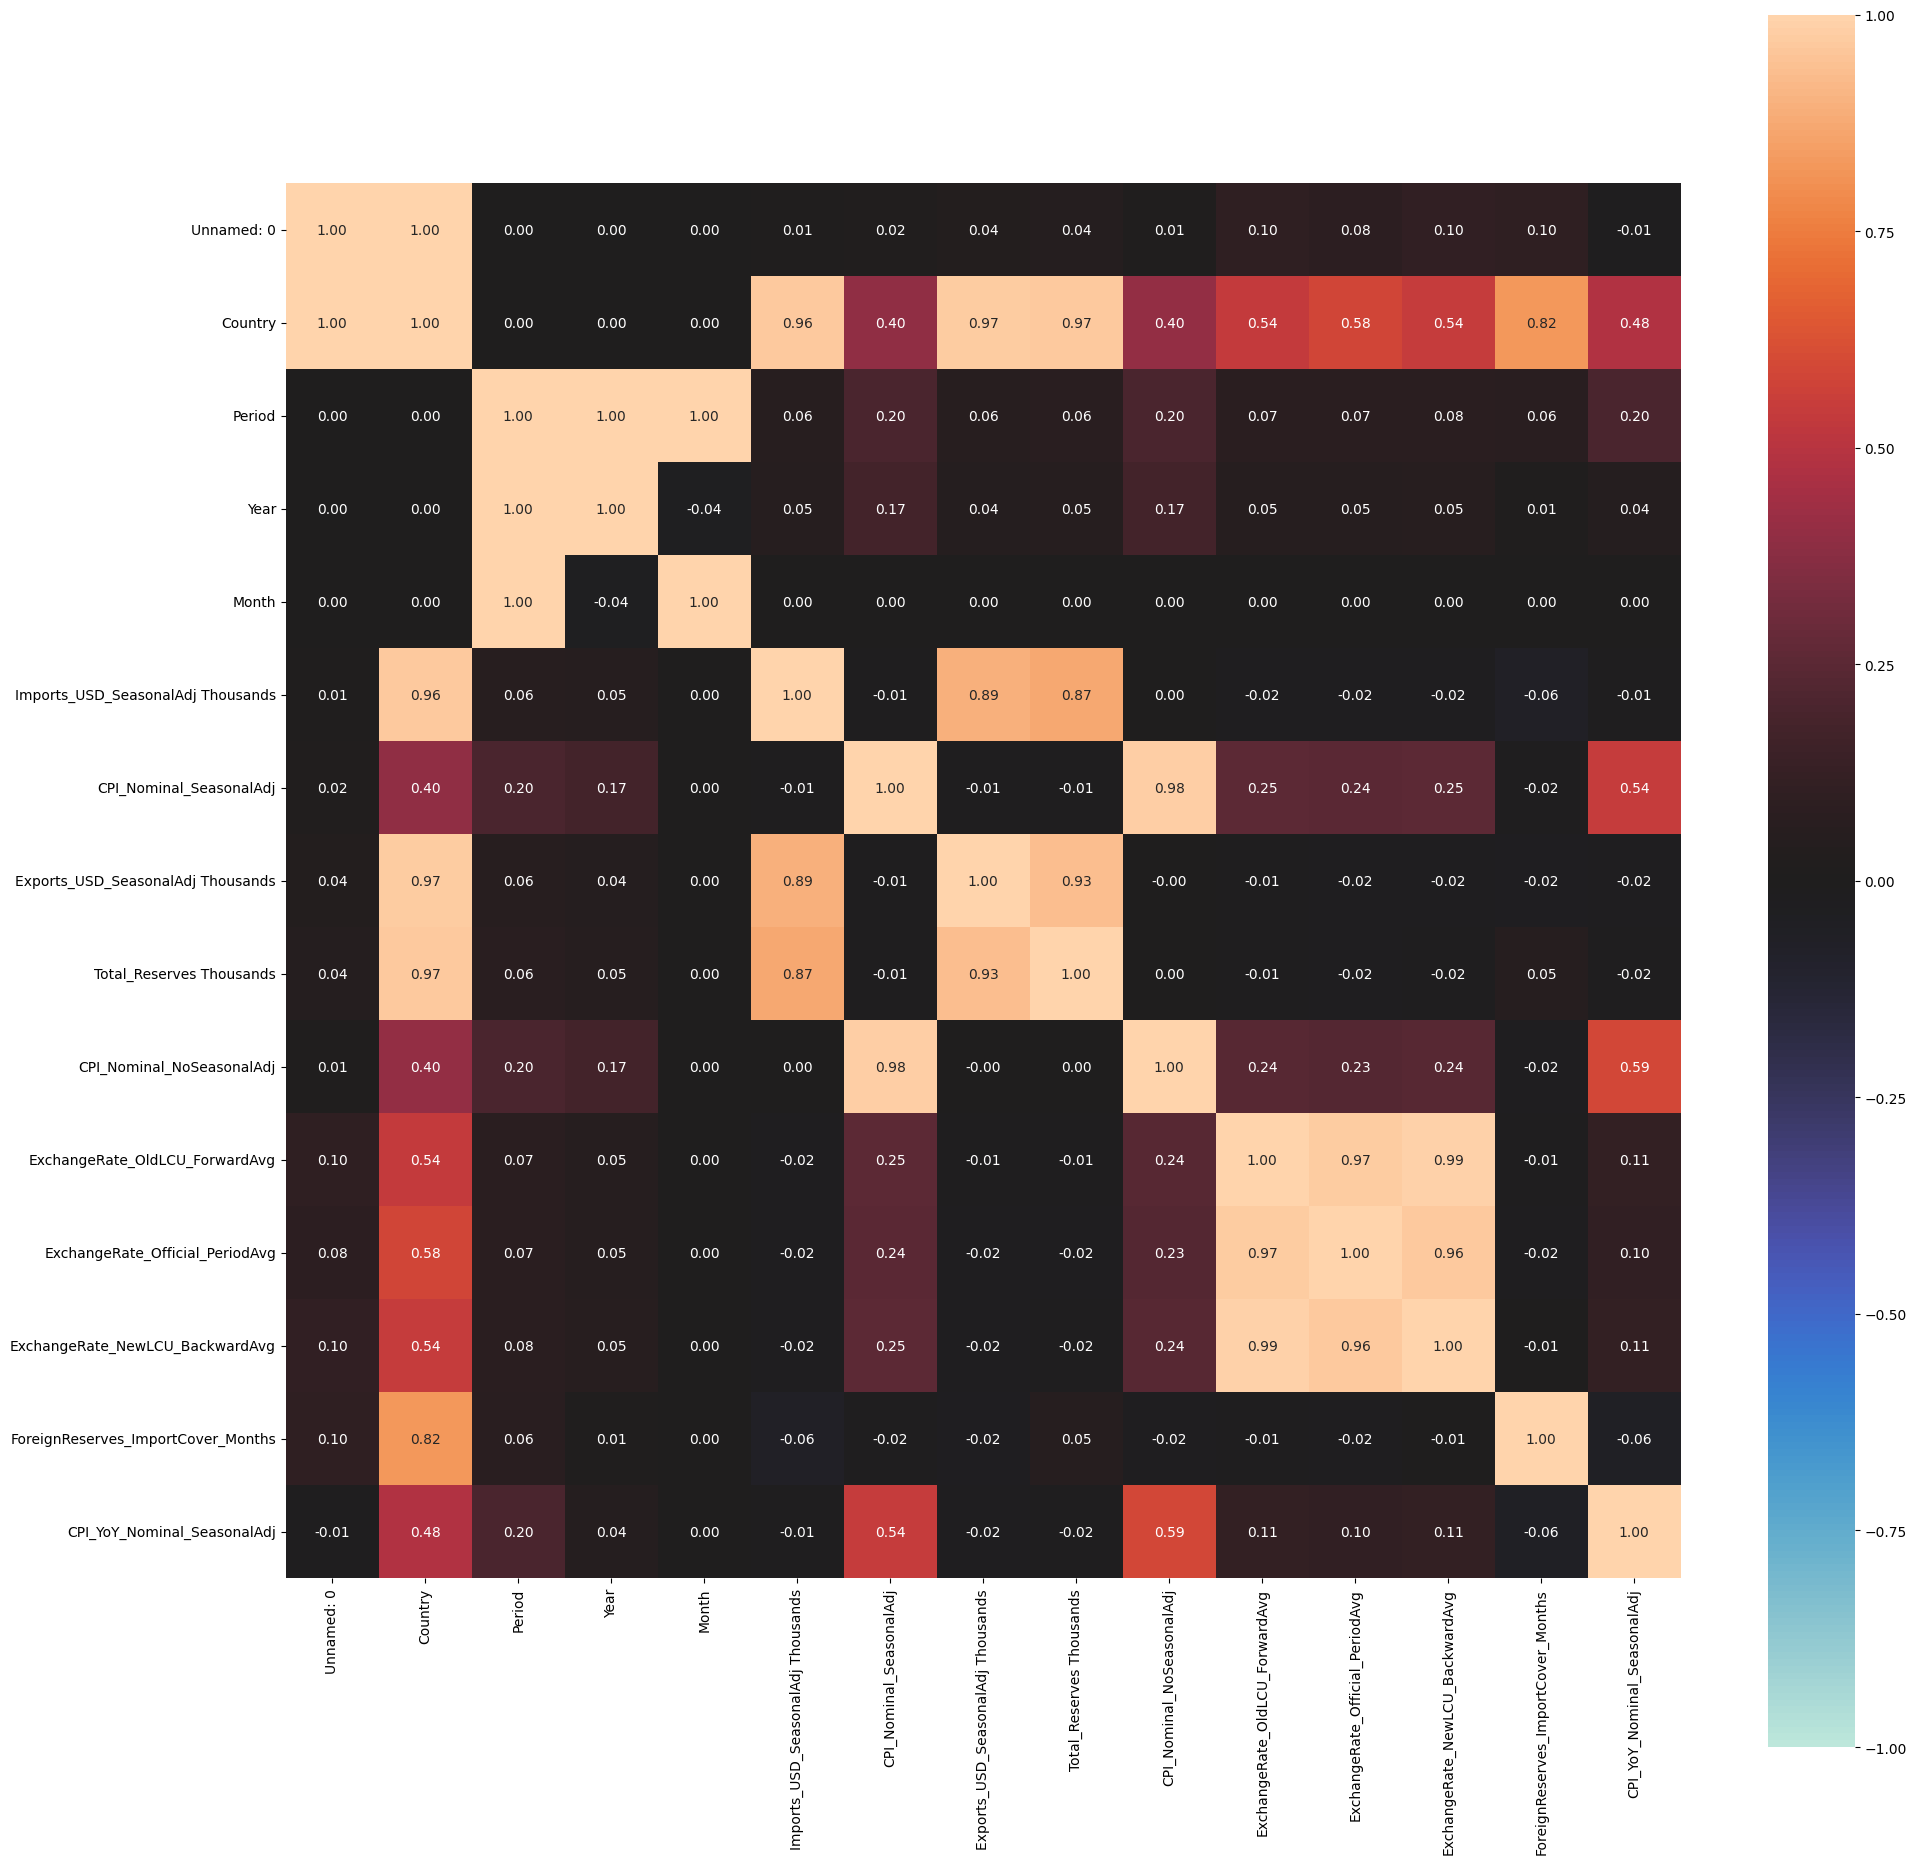

{'corr':                                     Unnamed: 0   Country    Period      Year  \
 Unnamed: 0                            1.000000  0.999989  0.004681  0.004675   
 Country                               0.999989  1.000000  0.000000  0.000000   
 Period                                0.004681  0.000000  1.000000  1.000000   
 Year                                  0.004675  0.000000  1.000000  1.000000   
 Month                                 0.000064  0.000000  1.000000 -0.037087   
 Imports_USD_SeasonalAdj Thousands     0.010101  0.962724  0.060872  0.052895   
 CPI_Nominal_SeasonalAdj               0.020915  0.396122  0.195838  0.173009   
 Exports_USD_SeasonalAdj Thousands     0.037262  0.974189  0.055432  0.043078   
 Total_Reserves Thousands              0.044253  0.966641  0.063527  0.052721   
 CPI_Nominal_NoSeasonalAdj             0.014456  0.401562  0.196985  0.174566   
 ExchangeRate_OldLCU_ForwardAvg        0.097704  0.537805  0.071341  0.046962   
 ExchangeRate_Offici

In [ ]:
associations(df, nominal_columns='auto')

In [9]:
# drop forward and backward exchange rate having 0.99 association, maintain official exchange rate which has 0.96 to the two
df = df.drop(columns=['Unnamed: 0', 'ExchangeRate_OldLCU_ForwardAvg', 'ExchangeRate_NewLCU_BackwardAvg'])

In [ ]:
df.tail()

,Country,Year,Month,Imports_USD_SeasonalAdj Thousands,CPI_Nominal_SeasonalAdj,Exports_USD_SeasonalAdj Thousands,Total_Reserves Thousands,CPI_Nominal_NoSeasonalAdj,ExchangeRate_Official_PeriodAvg,ForeignReserves_ImportCover_Months,CPI_YoY_Nominal_SeasonalAdj
Period,,,,,,,,,,,
2025-03-01,Zambia,2025,3,1.715596,488.268500,1.016063,4.465200,490.553300,28.66981,2.639312,16.593610
2025-04-01,Zambia,2025,4,1.709671,493.374100,0.996673,4.663820,495.257600,28.17118,2.849180,16.556740
2025-05-01,Zambia,2025,5,1.641321,495.678400,1.035429,5.201933,496.914600,27.00702,3.096936,15.360480
2025-06-01,Zambia,2025,6,1.564673,497.552300,1.092598,10.939326,497.866900,24.65560,7.031990,14.173190
2025-07-01,Zambia,2025,7,4.540155,91.411058,3.745340,23.361040,91.805647,23.90032,5.022313,6.005859


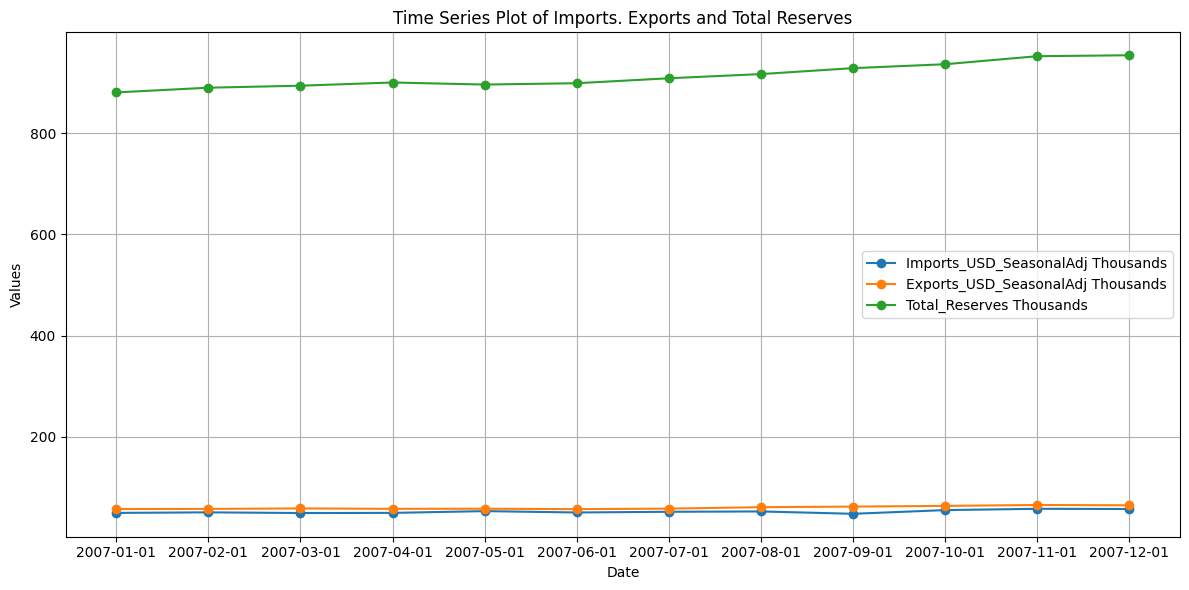

In [ ]:
dfgh = df[['Period','Imports_USD_SeasonalAdj Thousands','Exports_USD_SeasonalAdj Thousands','Total_Reserves Thousands']][(df['Country'] == 'Japan') & (df['Year'] == 2007)]
#dfgh.set_index('Period', inplace=True)
plt.figure(figsize=(12, 6))
for column in ['Imports_USD_SeasonalAdj Thousands','Exports_USD_SeasonalAdj Thousands','Total_Reserves Thousands']:
    plt.plot(dfgh['Period'], dfgh[column], marker='o', label=column)

plt.title('Time Series Plot of Imports. Exports and Total Reserves')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df15 = df[df['Year'] >= 2015].reset_index(drop=True)

In [ ]:
df15.head()

,Country,Period,Year,Month,Imports_USD_SeasonalAdj Thousands,CPI_Nominal_SeasonalAdj,Exports_USD_SeasonalAdj Thousands,Total_Reserves Thousands,CPI_Nominal_NoSeasonalAdj,ExchangeRate_Official_PeriodAvg,ForeignReserves_ImportCover_Months,CPI_YoY_Nominal_SeasonalAdj
0,Advanced Economies,2015-01-01,2015,1,821.9618,107.2984,810.9243,4251.781,107.2878,336.72624,5.172723,4.136690
1,Advanced Economies,2015-02-01,2015,2,811.9696,107.4749,798.8325,4290.692,107.6668,336.72624,5.284301,4.364969
2,Advanced Economies,2015-03-01,2015,3,822.9391,107.7121,791.8830,4282.589,108.1986,336.72624,5.204016,4.364969
3,Advanced Economies,2015-04-01,2015,4,815.6897,107.7899,786.1404,4326.891,108.4849,336.72624,5.304580,4.364969
4,Advanced Economies,2015-05-01,2015,5,792.8969,108.0482,780.2166,4314.507,108.8605,336.72624,5.441447,4.270237


In [ ]:
numeric_cols = [
    "Imports_USD_SeasonalAdj Thousands",
    "CPI_Nominal_SeasonalAdj",
    "Exports_USD_SeasonalAdj Thousands",
    "Total_Reserves Thousands",
    "CPI_Nominal_NoSeasonalAdj",
    "ExchangeRate_Official_PeriodAvg",
    "ForeignReserves_ImportCover_Months",
    "CPI_YoY_Nominal_SeasonalAdj"
]

# Calcolo della media per paese
dfMeans = df15.groupby("Country")[numeric_cols].mean().reset_index()

In [ ]:
dfMeans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             142 non-null    object 
 1   Imports_USD_SeasonalAdj Thousands   142 non-null    float64
 2   CPI_Nominal_SeasonalAdj             142 non-null    float64
 3   Exports_USD_SeasonalAdj Thousands   142 non-null    float64
 4   Total_Reserves Thousands            142 non-null    float64
 5   CPI_Nominal_NoSeasonalAdj           142 non-null    float64
 6   ExchangeRate_Official_PeriodAvg     142 non-null    float64
 7   ForeignReserves_ImportCover_Months  142 non-null    float64
 8   CPI_YoY_Nominal_SeasonalAdj         142 non-null    float64
dtypes: float64(8), object(1)
memory usage: 10.1+ KB


## Serie temporale

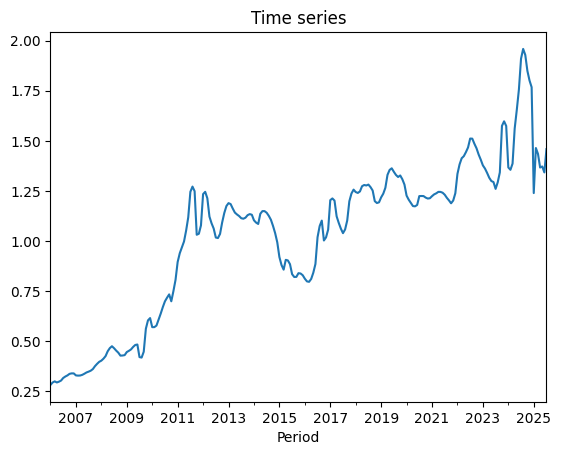

In [71]:
serie = df[df['Country'] == 'Ghana']['Exports_USD_SeasonalAdj Thousands']
serie.index = pd.to_datetime(serie.index)
serie = serie.asfreq('MS')
serie.plot(title="Time series")
plt.show()

### Modello SARIMAX

### Grid search for optimal parameters

In [62]:
from tqdm import tqdm  # utile per visualizzare progresso

# -------------------------
# Definizione spazi parametri
# -------------------------
p = d = q = range(0, 2)   # valori possibili per ARIMA
pdq = list(itertools.product(p, d, q))

# parametri stagionali con periodicità 12 (dati mensili → stagionalità annuale)
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq]

# -------------------------
# Grid search
# -------------------------
best_aic = float("inf")
best_params = None
results = []

print(f"Total combinations: {len(pdq) * len(seasonal_pdq)}")

for param in tqdm(pdq, desc="SARIMAX parameters search"):
    for param_seasonal in seasonal_pdq:
        try:
            modello = SARIMAX(
                trans,
                order=param,
                seasonal_order=param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            risultati = modello.fit(disp=False)
            aic = risultati.aic

            results.append((param, param_seasonal, aic))

            if aic < best_aic:
                best_aic = aic
                best_params = (param, param_seasonal)

        except Exception:
            # Ignora modelli non validi
            continue

# -------------------------
# Risultati
# -------------------------
results_df = pd.DataFrame(results, columns=["order", "seasonal_order", "AIC"])
results_df = results_df.sort_values(by="AIC", ascending=True).reset_index(drop=True)

print("\nBest model found:")
print("order =", best_params[0])
print("seasonal_order =", best_params[1])
print("AIC =", best_aic)

# Mostra top 5 modelli
print("\nTop 5 models:")
print(results_df.head())



Total combinations: 64


SARIMAX parameters search: 100%|██████████| 8/8 [00:26<00:00,  3.26s/it]


Best model found:
order = (1, 1, 0)
seasonal_order = (0, 0, 0, 12)
AIC = -532.5770828847017

Top 5 modelli:
       order seasonal_order         AIC
0  (1, 1, 0)  (0, 0, 0, 12) -532.577083
1  (1, 0, 1)  (0, 0, 0, 12) -531.739293
2  (0, 1, 1)  (0, 0, 0, 12) -530.782914
3  (1, 1, 1)  (0, 0, 0, 12) -529.332662
4  (1, 0, 0)  (0, 0, 0, 12) -517.968031


#### rifitto best modello con una metodologia di ottimizzazione piu robusta

In [63]:
best_order, best_seasonal = best_params

final_model = SARIMAX(
    serie,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=True,
    enforce_invertibility=True
)

final_results = final_model.fit(method="powell", disp=False)
print(final_results.summary())

                                       SARIMAX Results                                       
Dep. Variable:     Exports_USD_SeasonalAdj Thousands   No. Observations:                  235
Model:                              SARIMAX(1, 1, 0)   Log Likelihood                -449.663
Date:                               Mon, 15 Sep 2025   AIC                            903.326
Time:                                       20:52:31   BIC                            910.236
Sample:                                   01-01-2006   HQIC                           906.112
                                        - 07-01-2025                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4313      0.072     -5.968      0.000      -0.573      -0.290
sigma2     

In [ ]:

print("NumPy version:", np.__version__)
print("pmdarima version:", pm.__version__)

NumPy version: 2.3.3


NameError: name 'pm' is not defined

In [64]:
modello = SARIMAX(serie,
                  order=(1,1,1),
                  seasonal_order=(0,1,1,12),
                  enforce_stationarity=False,
                  enforce_invertibility=False)

risultati1 = modello.fit()
print(risultati1.summary())

                                       SARIMAX Results                                       
Dep. Variable:     Exports_USD_SeasonalAdj Thousands   No. Observations:                  235
Model:                SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -419.714
Date:                               Mon, 15 Sep 2025   AIC                            847.428
Time:                                       20:53:12   BIC                            860.778
Sample:                                   01-01-2006   HQIC                           852.826
                                        - 07-01-2025                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3201      0.188     -1.706      0.088      -0.688       0.048
ma.L1      

### Outliers


In [ ]:
### Model with preprocessed data

In [58]:
from scipy import stats
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

def identify_multiple_outliers(series, methods=['zscore', 'iqr', 'isolation']):
    """
    Identify outliers using different methods
    """
    outliers_dict = {}

    print("=== OUTLIER IDENTIFICATION ===")

    # Method 1: Z-Score
    if 'zscore' in methods:
        z_scores = np.abs(stats.zscore(series.dropna()))
        outliers_zscore = series.dropna().index[z_scores > 3]
        outliers_dict['zscore'] = outliers_zscore
        print(f"Z-Score (>3): {len(outliers_zscore)} outliers")

    # Method 2: IQR (Interquartile Range)
    if 'iqr' in methods:
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_iqr = series.index[(series < lower_bound) | (series > upper_bound)]
        outliers_dict['iqr'] = outliers_iqr
        print(f"IQR (1.5*IQR): {len(outliers_iqr)} outliers")
        print(f"  Normal range: [{lower_bound:.2f}, {upper_bound:.2f}]")

    # Method 3: Isolation Forest (more sophisticated)
    if 'isolation' in methods:
        from sklearn.ensemble import IsolationForest

        # Prepare data for Isolation Forest
        X = series.dropna().values.reshape(-1, 1)
        iso_forest = IsolationForest(contamination=0.1, random_state=42)
        outliers_mask = iso_forest.fit_predict(X) == -1

        outliers_isolation = series.dropna().index[outliers_mask]
        outliers_dict['isolation'] = outliers_isolation
        print(f"Isolation Forest: {len(outliers_isolation)} outliers")

    # Consensus outliers (agreement among methods)
    if len(outliers_dict) > 1:
        all_outliers = set()
        for outliers in outliers_dict.values():
            all_outliers.update(outliers)

        # Count how many methods detect each outlier
        consensus = {}
        for outlier in all_outliers:
            count = sum(1 for outliers in outliers_dict.values() if outlier in outliers)
            consensus[outlier] = count

        # Outliers detected by at least 2 methods
        consensus_outliers = [k for k, v in consensus.items() if v >= 2]
        outliers_dict['consensus'] = consensus_outliers
        print(f"Consensus (>=2 methods): {len(consensus_outliers)} outliers")

    return outliers_dict


def visualize_outliers(series, outliers_dict):
    """
    Visualize identified outliers
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Main plot with all outliers
    axes[0,0].plot(series, 'b-', alpha=0.7, label='Original series')

    colors = ['red', 'orange', 'purple', 'green']
    for i, (method, outliers) in enumerate(outliers_dict.items()):
        if len(outliers) > 0:
            axes[0,0].scatter(outliers, series[outliers],
                            color=colors[i % len(colors)],
                            s=50, label=f'{method} ({len(outliers)})')

    axes[0,0].set_title('Identified Outliers')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # Boxplot
    axes[0,1].boxplot(series.dropna())
    axes[0,1].set_title('Boxplot - IQR Visualization')
    axes[0,1].grid(True)

    # Distribution
    axes[1,0].hist(series.dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[1,0].set_title('Value Distribution')
    axes[1,0].grid(True)

    # Z-scores
    if len(series.dropna()) > 0:
        z_scores = stats.zscore(series.dropna())
        axes[1,1].plot(series.dropna().index, z_scores, 'g-', alpha=0.7)
        axes[1,1].axhline(y=3, color='r', linestyle='--', label='Threshold +3')
        axes[1,1].axhline(y=-3, color='r', linestyle='--', label='Threshold -3')
        axes[1,1].set_title('Z-Scores over Time')
        axes[1,1].legend()
        axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()


def remove_outliers_simple(series, outliers_to_remove):
    """
    Completely remove outliers (simple approach)
    """
    cleaned_series = series.drop(outliers_to_remove)

    print(f"=== SIMPLE REMOVAL ===")
    print(f"Original observations: {len(series)}")
    print(f"Removed outliers: {len(outliers_to_remove)}")
    print(f"Remaining observations: {len(cleaned_series)}")
    print(f"Removed percentage: {len(outliers_to_remove)/len(series)*100:.1f}%")

    return cleaned_series


def replace_outliers_interpolation(series, outliers_to_replace, method='linear'):
    """
    Replace outliers with interpolation
    """
    corrected_series = series.copy()

    # Mark outliers as NaN
    corrected_series.loc[outliers_to_replace] = np.nan

    # Interpolate
    if method == 'linear':
        corrected_series = corrected_series.interpolate(method='linear')
    elif method == 'spline':
        corrected_series = corrected_series.interpolate(method='spline', order=2)
    elif method == 'time':
        corrected_series = corrected_series.interpolate(method='time')

    print(f"=== INTERPOLATION REPLACEMENT ({method.upper()}) ===")
    print(f"Replaced outliers: {len(outliers_to_replace)}")

    return corrected_series


def replace_outliers_statistics(series, outliers_to_replace, method='median'):
    """
    Replace outliers with statistics (mean, median, etc.)
    """
    corrected_series = series.copy()

    if method == 'median':
        replacement_value = series.median()
    elif method == 'mean':
        replacement_value = series.mean()
    elif method == 'rolling_median':
        # Use rolling median (window of 5 periods)
        rolling_median = series.rolling(window=5, center=True).median()
        # Replace outliers with local rolling median
        for outlier in outliers_to_replace:
            if outlier in rolling_median.index:
                corrected_series.loc[outlier] = rolling_median.loc[outlier]
            else:
                corrected_series.loc[outlier] = series.median()

        print(f"=== REPLACEMENT WITH {method.upper()} ===")
        print(f"Replaced outliers: {len(outliers_to_replace)}")
        return corrected_series

    # Replace with single value
    corrected_series.loc[outliers_to_replace] = replacement_value

    print(f"=== REPLACEMENT WITH {method.upper()} ===")
    print(f"Replaced outliers: {len(outliers_to_replace)}")
    print(f"Replacement value: {replacement_value:.3f}")

    return corrected_series


def winsorize_outliers(series, percentiles=(5, 95)):
    """
    Winsorization: trim extremes to specified percentiles
    """
    lower_percentile = np.percentile(series.dropna(), percentiles[0])
    upper_percentile = np.percentile(series.dropna(), percentiles[1])

    winsorized_series = series.copy()
    winsorized_series = winsorized_series.clip(lower=lower_percentile, upper=upper_percentile)

    outliers_clipped = series.index[
        (series < lower_percentile) | (series > upper_percentile)
    ]

    print(f"=== WINSORIZATION ({percentiles[0]}-{percentiles[1]} percentiles) ===")
    print(f"Lower bound: {lower_percentile:.3f}")
    print(f"Upper bound: {upper_percentile:.3f}")
    print(f"Modified values: {len(outliers_clipped)}")

    return winsorized_series, outliers_clipped


def robust_transformation(series):
    """
    Robust transformation to reduce the impact of outliers
    """
    scaler = RobustScaler()

    # Reshape for sklearn
    values = series.dropna().values.reshape(-1, 1)
    values_scaled = scaler.fit_transform(values)

    # Create new series
    robust_series = pd.Series(
        values_scaled.flatten(),
        index=series.dropna().index,
        name=f"{series.name}_robust"
    )

    print("=== ROBUST TRANSFORMATION ===")
    print(f"Original median: {series.median():.3f}")
    print(f"Original MAD: {stats.median_abs_deviation(series.dropna()):.3f}")

    return robust_series, scaler


def compare_outlier_removal_methods(series, outliers_dict):
    """
    Compare different outlier treatment methods
    """
    if 'consensus' not in outliers_dict or len(outliers_dict['consensus']) == 0:
        print("No consensus outliers found. Using z-score.")
        outliers_to_treat = outliers_dict.get('zscore', [])
    else:
        outliers_to_treat = outliers_dict['consensus']

    if len(outliers_to_treat) == 0:
        print("No outliers to treat.")
        return

    treatment_methods = {}

    # 1. Complete removal
    treatment_methods['removed'] = remove_outliers_simple(series, outliers_to_treat)

    # 2. Linear interpolation
    treatment_methods['interpolated'] = replace_outliers_interpolation(
        series, outliers_to_treat, 'linear'
    )

    # 3. Rolling median replacement
    treatment_methods['rolling_median'] = replace_outliers_statistics(
        series, outliers_to_treat, 'rolling_median'
    )

    # 4. Winsorization
    treatment_methods['winsorized'], _ = winsorize_outliers(series)

    # Comparison plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    for i, (name, treated_series) in enumerate(treatment_methods.items()):
        row, col = i // 2, i % 2

        # Original series
        axes[row, col].plot(series, 'b-', alpha=0.5, label='Original')

        # Treated series
        axes[row, col].plot(treated_series, 'r-', alpha=0.8, label=f'{name.title()}')

        # Highlight original outliers
        if len(outliers_to_treat) > 0:
            valid_outliers = [o for o in outliers_to_treat if o in series.index]
            if valid_outliers:
                axes[row, col].scatter(valid_outliers, series[valid_outliers],
                                     color='orange', s=50, label='Original outliers')

        axes[row, col].set_title(f'Method: {name.title()}')
        axes[row, col].legend()
        axes[row, col].grid(True)

    plt.tight_layout()
    plt.show()

    return treatment_methods


def analyze_outlier_impact(original_series, treated_series, method_name="Treatment"):
    """
    Analyze the impact of outlier treatment on statistics
    """
    print(f"\n=== IMPACT {method_name.upper()} ===")

    stats_original = {
        'Mean': original_series.mean(),
        'Median': original_series.median(),
        'Std Dev': original_series.std(),
        'Skewness': stats.skew(original_series.dropna()),
        'Kurtosis': stats.kurtosis(original_series.dropna(), fisher=True),
        'Min': original_series.min(),
        'Max': original_series.max()
    }

    stats_treated = {
        'Mean': treated_series.mean(),
        'Median': treated_series.median(),
        'Std Dev': treated_series.std(),
        'Skewness': stats.skew(treated_series.dropna()),
        'Kurtosis': stats.kurtosis(treated_series.dropna(), fisher=True),
        'Min': treated_series.min(),
        'Max': treated_series.max()
    }

    # Comparison table
    comparison = pd.DataFrame({
        'Original': stats_original,
        'Treated': stats_treated
    })

    comparison['Difference'] = comparison['Treated'] - comparison['Original']
    comparison['Diff %'] = (comparison['Difference'] / comparison['Original'] * 100).round(2)

    print(comparison.round(4))

    return comparison


# Our case
def handle_outliers_ghana_series(series):
    """
    Complete pipeline to handle outliers in Ghana series
    """
    print("OUTLIERS MANAGEMENT - EXPORTS SERIES")
    print("=" * 60)

    # 1. Identify outliers with multiple methods
    outliers_dict = identify_multiple_outliers(series)

    # 2. Visualize outliers
    visualize_outliers(series, outliers_dict)

    # 3. Compare treatment methods
    treatment_methods = compare_outlier_removal_methods(series, outliers_dict)

    # Ensure methods are not None
    if treatment_methods is None or len(treatment_methods) == 0:
        print("No treatment applied. Original series maintained.")
        return {'original': series.copy()}, series.copy(), outliers_dict

    # 4. Analyze impact of each method
    for name, treated_series in treatment_methods.items():
        if name != 'original':  # Skip analysis for original series
            analyze_outlier_impact(series, treated_series, name)

    # 5. Recommendation
    print("\n=== SUGGESTIONS ===")

    outliers_to_treat = outliers_dict.get('consensus', outliers_dict.get('zscore', []))

    if len(outliers_to_treat) == 0:
        print("RECOMMENDATION: No significant outliers found")
        print("   - Series already clean, use the original series")
        recommended_series = series.copy()
    else:
        pct_outliers = len(outliers_to_treat) / len(series) * 100

        if pct_outliers < 2:
            print("SUGGESTION: Linear interpolation")
            print("   - Few outliers (<2%), interpolation preserves time structure")
            recommended_series = treatment_methods.get('interpolated', series.copy())
        elif pct_outliers < 5:
            print("SUGGESTION: Rolling median")
            print("   - Moderate outliers, rolling median is more robust")
            recommended_series = treatment_methods.get('rolling_median', series.copy())
        else:
            print("SUGGESTION: Winsorization")
            print("   - Many outliers, winsorization preserves more information")
            recommended_series = treatment_methods.get('winsorized', series.copy())

    return treatment_methods, recommended_series, outliers_dict


TRATTAMENTO OUTLIERS - SERIE GHANA EXPORTS
=== IDENTIFICAZIONE OUTLIERS ===
Z-Score (>3): 0 outliers
IQR (1.5*IQR): 6 outliers
  Range normale: [7.31, 29.38]
Isolation Forest: 24 outliers
Consensus (>=2 metodi): 6 outliers


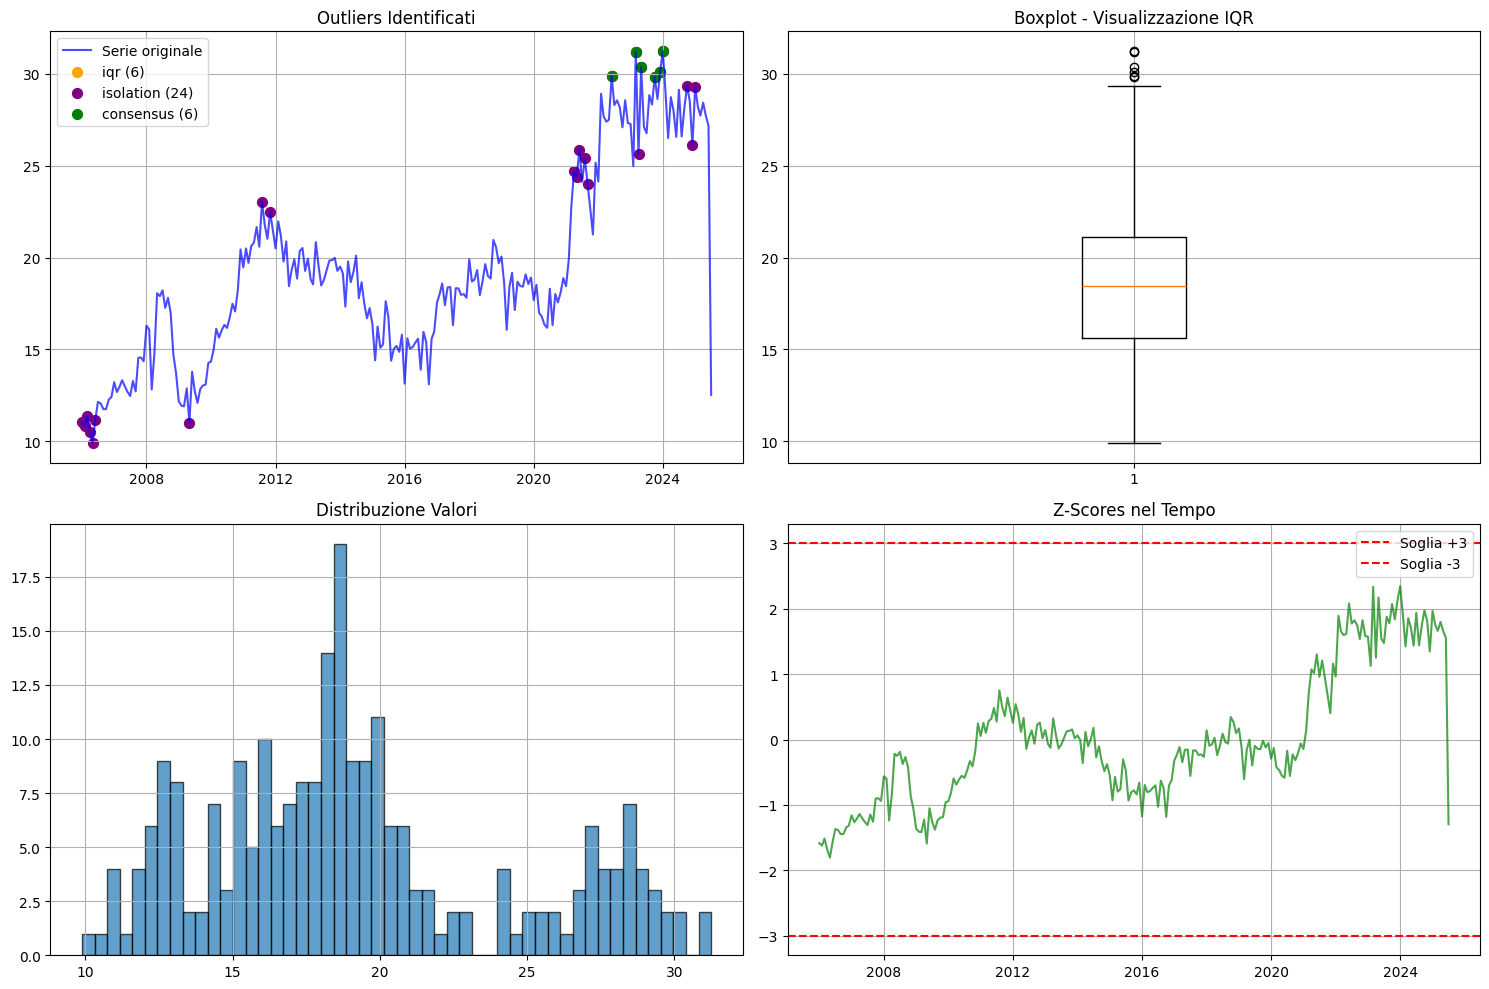

=== RIMOZIONE SEMPLICE ===
Osservazioni originali: 235
Outliers rimossi: 6
Osservazioni rimanenti: 229
Percentuale rimossa: 2.6%
=== SOSTITUZIONE CON INTERPOLAZIONE (LINEAR) ===
Outliers sostituiti: 6
=== SOSTITUZIONE CON ROLLING_MEDIAN ===
Outliers sostituiti: 6
=== WINSORIZATION (5-95 percentiles) ===
Lower bound: 12.071
Upper bound: 28.769
Modified values: 24


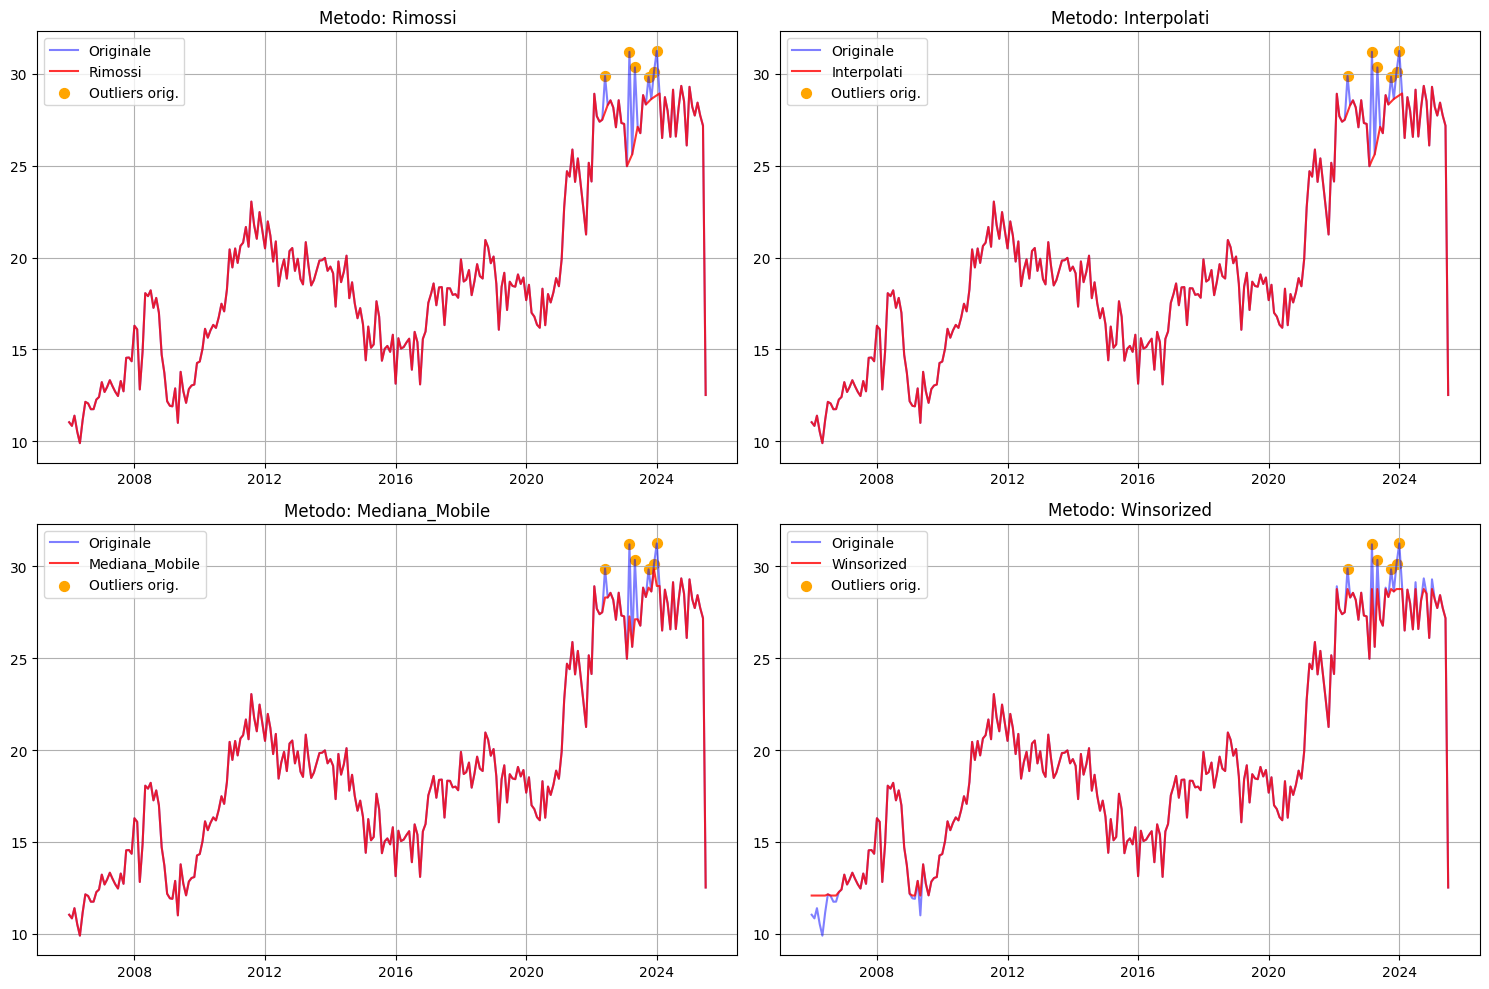


=== IMPATTO RIMOSSI ===
          Originale  Trattata  Differenza  Diff %
Media       19.1776   18.8824     -0.2952   -1.54
Mediana     18.4496   18.4101     -0.0395   -0.21
Std Dev      5.1566    4.8839     -0.2727   -5.29
Skewness     0.5791    0.5551     -0.0240   -4.15
Kurtosis    -0.4726   -0.4246      0.0480  -10.16
Min          9.8846    9.8846      0.0000    0.00
Max         31.2536   29.3492     -1.9043   -6.09

=== IMPATTO INTERPOLATI ===
          Originale  Trattata  Differenza  Diff %
Media       19.1776   19.1051     -0.0725   -0.38
Mediana     18.4496   18.4496      0.0000    0.00
Std Dev      5.1566    5.0187     -0.1379   -2.67
Skewness     0.5791    0.5088     -0.0703  -12.14
Kurtosis    -0.4726   -0.5868     -0.1142   24.16
Min          9.8846    9.8846      0.0000    0.00
Max         31.2536   29.3492     -1.9043   -6.09

=== IMPATTO MEDIANA_MOBILE ===
          Originale  Trattata  Differenza  Diff %
Media       19.1776   19.1251     -0.0525   -0.27
Mediana     18

In [59]:
# Tratta outliers
metodi_trattamento, serie_pulita, outliers_info = tratta_outliers_serie_ghana(serie)


In [33]:
# Usa la serie raccomandata per il modello SARIMAX
modello1 = SARIMAX(serie_pulita, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
fit1 = modello1.fit()
print(fit1.summary())

                                       SARIMAX Results                                       
Dep. Variable:     Exports_USD_SeasonalAdj Thousands   No. Observations:                  235
Model:                SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                 285.534
Date:                               Mon, 15 Sep 2025   AIC                           -565.068
Time:                                       19:00:30   BIC                           -554.860
Sample:                                   01-01-2006   HQIC                          -560.947
                                        - 07-01-2025                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2670      0.033      8.027      0.000       0.202       0.332
ar.S.L12   

### Trasformazione variabili

In [60]:
from scipy import stats
from scipy.stats import boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
import warnings
warnings.filterwarnings('ignore')

def test_eteroschedasticita(serie, nome="Serie"):
    """
    Testa l'eteroschedasticità con diversi metodi
    """
    print(f"\n=== TEST ETEROSCHEDASTICITÀ: {nome.upper()} ===")

    # Fit modello base per ottenere residui
    try:
        model = SARIMAX(serie, order=(1, 1, 0))
        fit = model.fit(disp=False)
        residui = fit.resid
        fitted_values = fit.fittedvalues

        # Test di White
        try:
            white_stat, white_pvalue = het_white(residui, fitted_values)
            print(f"White Test: statistica={white_stat:.3f}, p-value={white_pvalue:.6f}")
            if white_pvalue < 0.05:
                print(" ETEROSCHEDASTICITÀ RILEVATA (p < 0.05)")
            else:
                print("Omoschedasticità (p >= 0.05)")
        except Exception as e:
            print(f"White Test fallito: {e}")

        # Test di Breusch-Pagan
        try:
            bp_stat, bp_pvalue = het_breuschpagan(residui, fitted_values)[:2]
            print(f"Breusch-Pagan: statistica={bp_stat:.3f}, p-value={bp_pvalue:.6f}")
            if bp_pvalue < 0.05:
                print("  ETEROSCHEDASTICITÀ RILEVATA (p < 0.05)")
            else:
                print("  Omoschedasticità (p >= 0.05)")
        except Exception as e:
            print(f"Breusch-Pagan Test fallito: {e}")

        # Varianza rolling per visualizzare instabilità
        residui_squared = residui ** 2
        rolling_var = residui_squared.rolling(window=12).mean()

        # Coefficiente di variazione della varianza
        cv_var = rolling_var.std() / rolling_var.mean() * 100
        print(f"Coefficiente variazione varianza: {cv_var:.2f}%")

        return residui, fitted_values, rolling_var

    except Exception as e:
        print(f"Errore nel test: {e}")
        return None, None, None

def trasformazione_logaritmica(serie):
    """
    Trasformazione logaritmica (riduce eteroschedasticità moltiplicativa)
    """
    print("\n=== TRASFORMAZIONE LOGARITMICA ===")

    if (serie <= 0).any():
        # Shift per valori negativi o zero
        shift_value = abs(serie.min()) + 1
        serie_shifted = serie + shift_value
        print(f"Serie shiftata di +{shift_value:.3f} per valori <= 0")
        log_serie = np.log(serie_shifted)
        print("Formula applicata: log(x + shift)")
    else:
        log_serie = np.log(serie)
        print("Formula applicata: log(x)")

    log_serie.name = f"{serie.name}_log" if serie.name else "log_transformed"

    return log_serie

def trasformazione_radice_quadrata(serie):
    """
    Trasformazione radice quadrata (per varianza proporzionale alla media)
    """
    print("\n=== TRASFORMAZIONE RADICE QUADRATA ===")

    if (serie < 0).any():
        # Shift per valori negativi
        shift_value = abs(serie.min()) + 1
        serie_shifted = serie + shift_value
        print(f"Serie shiftata di +{shift_value:.3f} per valori negativi")
        sqrt_serie = np.sqrt(serie_shifted)
        print("Formula applicata: sqrt(x + shift)")
    else:
        sqrt_serie = np.sqrt(serie)
        print("Formula applicata: sqrt(x)")

    sqrt_serie.name = f"{serie.name}_sqrt" if serie.name else "sqrt_transformed"

    return sqrt_serie

def trasformazione_boxcox(serie):
    """
    Trasformazione Box-Cox (trova lambda ottimale automaticamente)
    """
    print("\n=== TRASFORMAZIONE BOX-COX ===")

    try:
        if (serie <= 0).any():
            # Shift per valori <= 0
            shift_value = abs(serie.min()) + 1
            serie_positive = serie + shift_value
            print(f"Serie shiftata di +{shift_value:.3f} per valori <= 0")
        else:
            serie_positive = serie

        # Trova lambda ottimale
        transformed_data, optimal_lambda = boxcox(serie_positive)

        print(f"Lambda ottimale: {optimal_lambda:.4f}")

        # Interpreta il lambda
        if abs(optimal_lambda) < 0.01:
            print("Lambda ≈ 0: equivale alla trasformazione logaritmica")
        elif abs(optimal_lambda - 0.5) < 0.01:
            print("Lambda ≈ 0.5: equivale alla trasformazione radice quadrata")
        elif abs(optimal_lambda - 1) < 0.01:
            print("Lambda ≈ 1: nessuna trasformazione necessaria")
        else:
            print(f"Lambda = {optimal_lambda:.4f}: trasformazione power")

        boxcox_serie = pd.Series(transformed_data, index=serie.index)
        boxcox_serie.name = f"{serie.name}_boxcox" if serie.name else "boxcox_transformed"

        return boxcox_serie, optimal_lambda

    except Exception as e:
        print(f"Errore nella trasformazione Box-Cox: {e}")
        return serie.copy(), None

def trasformazione_reciproca(serie):
    """
    Trasformazione reciproca (1/x, per varianza proporzionale a media^4)
    """
    print("\n=== TRASFORMAZIONE RECIPROCA ===")

    if (serie == 0).any():
        print("Impossibile: presenza di valori zero")
        return serie.copy()

    if (serie < 0).any():
        print("Attenzione: presenza di valori negativi")

    reciprocal_serie = 1 / serie
    reciprocal_serie.name = f"{serie.name}_reciprocal" if serie.name else "reciprocal_transformed"

    print("Formula applicata: 1/x")

    return reciprocal_serie

def trasformazione_arcsin(serie):
    """
    Trasformazione arcoseno (per dati in proporzioni/percentuali)
    """
    print("\n=== TRASFORMAZIONE ARCOSENO ===")

    # Normalizza tra 0 e 1 se necessario
    if serie.max() > 1 or serie.min() < 0:
        serie_norm = (serie - serie.min()) / (serie.max() - serie.min())
        print("Serie normalizzata tra 0 e 1")
    else:
        serie_norm = serie

    # Evita valori esattamente 0 o 1
    serie_norm = np.clip(serie_norm, 0.001, 0.999)

    arcsin_serie = np.arcsin(np.sqrt(serie_norm))
    arcsin_serie.name = f"{serie.name}_arcsin" if serie.name else "arcsin_transformed"

    print("Formula applicata: arcsin(sqrt(x)) con x normalizzato [0,1]")

    return arcsin_serie

def differenziazione_per_eteroschedasticita(serie, ordini=[1, 2]):
    """
    Differenziazione per stabilizzare varianza (oltre che media)
    """
    print("\n=== DIFFERENZIAZIONE PER STABILIZZARE VARIANZA ===")

    risultati = {}

    for ordine in ordini:
        diff_serie = serie.copy()

        for i in range(ordine):
            diff_serie = diff_serie.diff().dropna()

        diff_serie.name = f"{serie.name}_diff{ordine}" if serie.name else f"diff{ordine}_transformed"
        risultati[f'diff_{ordine}'] = diff_serie

        print(f"Differenza ordine {ordine}: {len(diff_serie)} osservazioni")

    return risultati

def confronta_trasformazioni_complete(serie):
    """
    Confronta tutte le trasformazioni disponibili
    """
    print("CONFRONTO COMPLETO TRASFORMAZIONI")
    print("=" * 60)

    trasformazioni = {}

    # Serie originale
    trasformazioni['originale'] = serie.copy()

    # Trasformazioni standard
    trasformazioni['logaritmica'] = trasformazione_logaritmica(serie)
    trasformazioni['radice_quadrata'] = trasformazione_radice_quadrata(serie)
    trasformazioni['reciproca'] = trasformazione_reciproca(serie)
    trasformazioni['arcsin'] = trasformazione_arcsin(serie)

    # Box-Cox
    boxcox_serie, lambda_val = trasformazione_boxcox(serie)
    trasformazioni['boxcox'] = boxcox_serie

    # Differenziazione
    diff_results = differenziazione_per_eteroschedasticita(serie)
    trasformazioni.update(diff_results)

    return trasformazioni, lambda_val

def valuta_trasformazioni(trasformazioni):
    """
    Valuta l'efficacia di ogni trasformazione
    """
    print("\n" + "=" * 60)
    print("VALUTAZIONE TRASFORMAZIONI")
    print("=" * 60)

    risultati = []

    for nome, serie_trasformata in trasformazioni.items():
        if len(serie_trasformata.dropna()) < 10:
            print(f"{nome}: troppo poche osservazioni dopo trasformazione")
            continue

        print(f"\n--- {nome.upper()} ---")

        try:
            # Test eteroschedasticità
            residui, fitted_values, rolling_var = test_eteroschedasticita(serie_trasformata, nome)

            if residui is not None:
                # Statistiche descrittive
                skewness = stats.skew(serie_trasformata.dropna())
                kurtosis = stats.kurtosis(serie_trasformata.dropna(), fisher=True)

                # Jarque-Bera test
                jb_stat, jb_pvalue = jarque_bera(residui)

                # AIC del modello
                model = SARIMAX(serie_trasformata, order=(1, 1, 0))
                fit = model.fit(disp=False)
                aic_value = fit.aic

                print(f"AIC: {aic_value:.3f}")
                print(f"Skewness: {skewness:.3f}")
                print(f"Kurtosis: {kurtosis:.3f}")
                print(f"Jarque-Bera p-value: {jb_pvalue:.6f}")

                risultati.append({
                    'trasformazione': nome,
                    'aic': aic_value,
                    'skewness': abs(skewness),
                    'kurtosis': abs(kurtosis),
                    'jarque_bera_p': jb_pvalue,
                    'serie': serie_trasformata
                })

        except Exception as e:
            print(f"Errore nella valutazione: {e}")
            continue

    if risultati:
        # Crea DataFrame risultati
        df_risultati = pd.DataFrame(risultati)

        # Ordina per AIC (più basso = migliore)
        df_risultati_sorted = df_risultati.sort_values('aic')

        print(f"\n{'='*60}")
        print("CLASSIFICA TRASFORMAZIONI (per AIC)")
        print(f"{'='*60}")

        for i, row in df_risultati_sorted.iterrows():
            print(f"{row['trasformazione']:15} | AIC: {row['aic']:8.3f} | "
                  f"Skew: {row['skewness']:6.3f} | Kurt: {row['kurtosis']:6.3f} | "
                  f"JB p-val: {row['jarque_bera_p']:.6f}")

        return df_risultati_sorted

    return pd.DataFrame()

def visualizza_trasformazioni(trasformazioni):
    """
    Visualizza graficamente le trasformazioni
    """
    n_trasformazioni = len(trasformazioni)

    # Calcola layout griglia
    n_cols = 3
    n_rows = int(np.ceil(n_trasformazioni / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for i, (nome, serie) in enumerate(trasformazioni.items()):
        row, col = i // n_cols, i % n_cols

        # Plot serie temporale
        axes[row, col].plot(serie, alpha=0.8)
        axes[row, col].set_title(f'{nome.title()}')
        axes[row, col].grid(True, alpha=0.3)

        # Aggiungi statistiche nel titolo
        if len(serie.dropna()) > 0:
            mean_val = serie.mean()
            std_val = serie.std()
            axes[row, col].set_title(f'{nome.title()}\n(μ={mean_val:.2f}, σ={std_val:.2f})')

    # Nascondere subplot vuoti
    for i in range(n_trasformazioni, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].set_visible(False)

    plt.tight_layout()
    plt.show()

def visualizza_residui_comparati(trasformazioni_top3):
    """
    Confronta i residui delle migliori 3 trasformazioni
    """
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))

    for i, (nome, serie) in enumerate(trasformazioni_top3.items()):
        if i >= 3:  # Solo prime 3
            break

        try:
            model = SARIMAX(serie, order=(1, 1, 0))
            fit = model.fit(disp=False)
            residui = fit.resid

            # Serie temporale residui
            axes[i, 0].plot(residui, alpha=0.8)
            axes[i, 0].set_title(f'{nome}: Residui nel Tempo')
            axes[i, 0].grid(True, alpha=0.3)

            # Distribuzione residui
            axes[i, 1].hist(residui, bins=20, alpha=0.7, density=True)
            # Sovrapponi normale
            x = np.linspace(residui.min(), residui.max(), 100)
            axes[i, 1].plot(x, stats.norm.pdf(x, residui.mean(), residui.std()), 'r-')
            axes[i, 1].set_title(f'{nome}: Distribuzione Residui')
            axes[i, 1].grid(True, alpha=0.3)

            # Q-Q plot
            stats.probplot(residui, dist="norm", plot=axes[i, 2])
            axes[i, 2].set_title(f'{nome}: Q-Q Plot')
            axes[i, 2].grid(True, alpha=0.3)

        except Exception as e:
            print(f"Errore per {nome}: {e}")

    plt.tight_layout()
    plt.show()

# FUNZIONE PRINCIPALE
def trova_trasformazione_ottimale(serie):
    """
    Pipeline completa per trovare la trasformazione ottimale
    """
    print("RICERCA TRASFORMAZIONE OTTIMALE PER RIDURRE ETEROSCHEDASTICITÀ")
    print("=" * 80)

    # 1. Test iniziale
    print("1. ANALISI SERIE ORIGINALE")
    test_eteroschedasticita(serie, "Originale")

    # 2. Prova tutte le trasformazioni
    print("\n2. APPLICAZIONE TRASFORMAZIONI")
    trasformazioni, lambda_boxcox = confronta_trasformazioni_complete(serie)

    # 3. Visualizza trasformazioni
    print("\n3. VISUALIZZAZIONE TRASFORMAZIONI")
    visualizza_trasformazioni(trasformazioni)

    # 4. Valuta trasformazioni
    print("\n4. VALUTAZIONE TRASFORMAZIONI")
    risultati_df = valuta_trasformazioni(trasformazioni)

    if len(risultati_df) > 0:
        # 5. Trasformazione migliore
        migliore = risultati_df.iloc[0]
        print(f"\n TRASFORMAZIONE RACCOMANDATA: {migliore['trasformazione'].upper()}")
        print(f"   - AIC: {migliore['aic']:.3f}")
        print(f"   - Riduzione asimmetria: {abs(migliore['skewness']):.3f}")
        print(f"   - Riduzione curtosi: {abs(migliore['kurtosis']):.3f}")

        # 6. Visualizza residui delle migliori
        if len(risultati_df) >= 3:
            print("\n5. CONFRONTO RESIDUI (Top 3)")
            top3_dict = {row['trasformazione']: row['serie']
                        for _, row in risultati_df.head(3).iterrows()}
            visualizza_residui_comparati(top3_dict)

        return migliore['serie'], migliore['trasformazione'], risultati_df
    else:
        print("Nessuna trasformazione valida trovata")
        return serie.copy(), 'originale', pd.DataFrame()


In [14]:
# Esempio Brazil
def esempio_uso_ghana(serie_pulita):
    print("ESEMPIO D'USO - TRASFORMAZIONE SERIE Brazil")
    print("=" * 60)


    # Trova trasformazione ottimale
    serie_trasformata, nome_trasformazione, risultati = trova_trasformazione_ottimale(serie_pulita)

    # Usa la serie trasformata per SARIMAX
    model = SARIMAX(serie_trasformata, order=(1, 1, 0))
    fit = model.fit()
    print(fit.summary())

    # # Test finale eteroschedasticità
    print(f"\nTEST FINALE - SERIE {nome_trasformazione.upper()}")
    test_eteroschedasticita(serie_trasformata, nome_trasformazione)
    print(serie_trasformata)
    pass  # Placeholder per l'esempio

    return serie_trasformata, nome_trasformazione, risultati

serieTransformed = esempio_uso_ghana(serie_pulita)

NameError: name 'serie_pulita' is not defined

In [61]:
# USO RAPIDO - SOLO UNA TRASFORMAZIONE SPECIFICA
def applica_trasformazione_specifica(serie_pulita, tipo='log'):
    """
    Applica una trasformazione specifica
    """
    if tipo == 'log':
        return trasformazione_logaritmica(serie_pulita)
    elif tipo == 'sqrt':
        return trasformazione_radice_quadrata(serie_pulita)
    elif tipo == 'boxcox':
        transformed, lambda_val = trasformazione_boxcox(serie_pulita)
        return transformed
    elif tipo == 'reciprocal':
        return trasformazione_reciproca(serie_pulita)
    elif tipo == 'arcsin':
        return trasformazione_arcsin(serie_pulita)
    else:
        print(f"Tipo {tipo} non riconosciuto. Uso log.")
        transformed, _ = trasformazione_boxcox(serie_pulita)
        return transformed
trans = applica_trasformazione_specifica(serie_pulita, tipo='boxcox')


=== TRASFORMAZIONE BOX-COX ===
Lambda ottimale: -0.0384
Lambda = -0.0384: trasformazione power


### Grid search

### Modello post eliminazione outliers e trasfomazione

In [65]:
modello2 = SARIMAX(trans,
                  order=(1,0,1),
                  seasonal_order=(0,0,0,12),
                  enforce_stationarity=False,
                  enforce_invertibility=False)

risultati = modello2.fit()
print(risultati.summary())

                                          SARIMAX Results                                           
Dep. Variable:     Exports_USD_SeasonalAdj Thousands_boxcox   No. Observations:                  235
Model:                                     SARIMAX(1, 0, 1)   Log Likelihood                 268.870
Date:                                      Mon, 15 Sep 2025   AIC                           -531.739
Time:                                              20:53:38   BIC                           -521.386
Sample:                                          01-01-2006   HQIC                          -527.564
                                               - 07-01-2025                                         
Covariance Type:                                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0003      0.002  

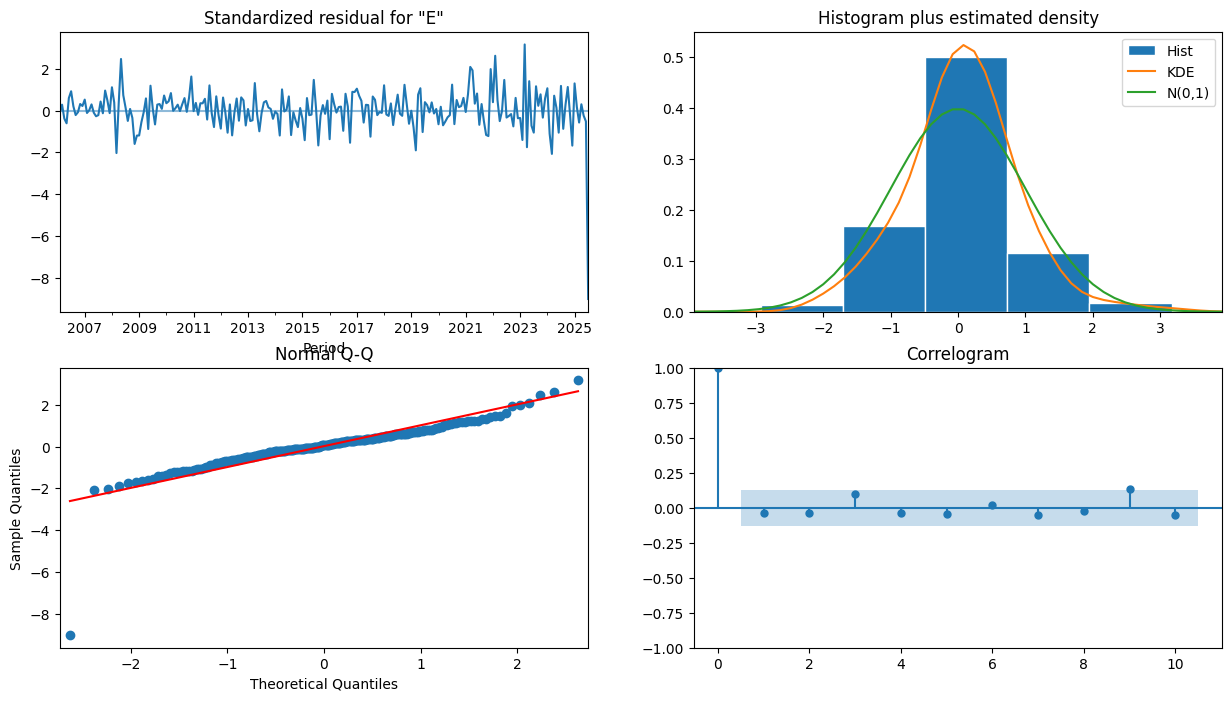

In [66]:
final_results.plot_diagnostics(figsize=(15, 8))
plt.show()

### Previsione

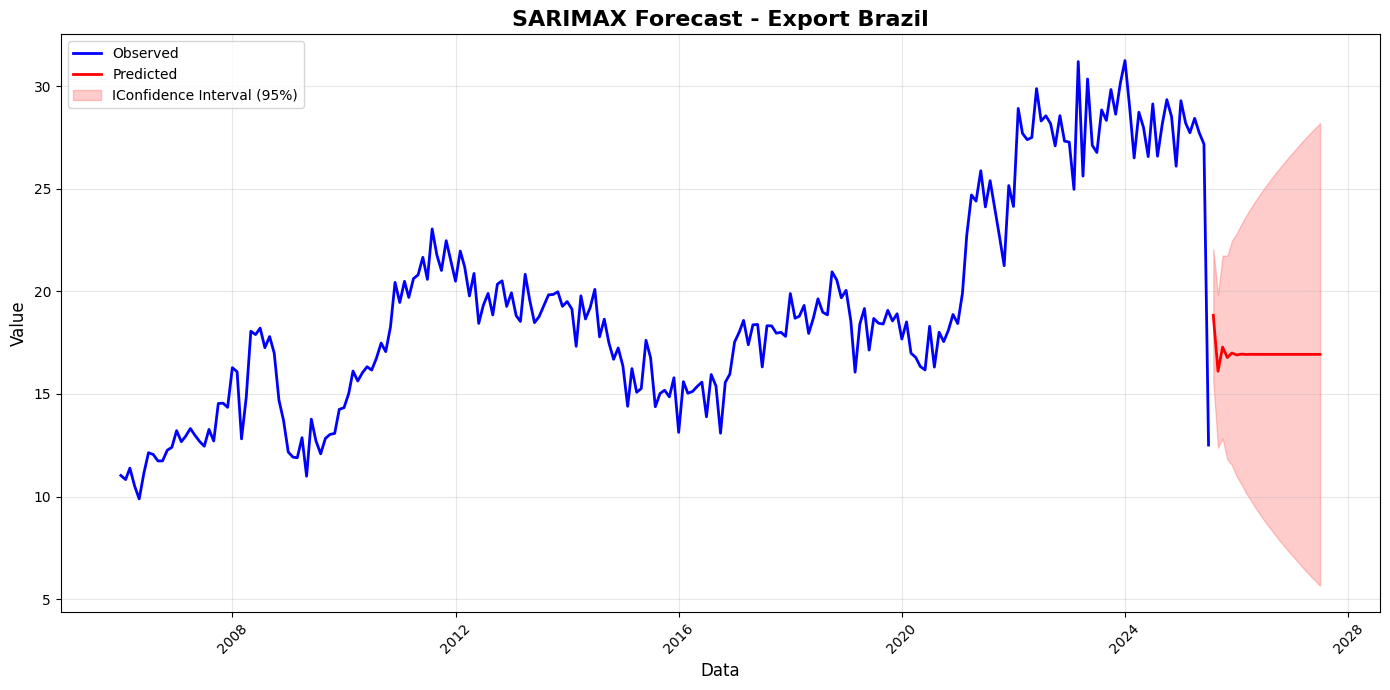

In [68]:

# Numero di periodi futuri da prevedere
n_forecast = 24

# Calcolo delle previsioni
forecast = final_results.get_forecast(steps=n_forecast)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Genera l'indice futuro con la stessa frequenza della serie originale
freq = pd.infer_freq(serie.index) or "M"  # fallback a mensile se non riconosciuta
future_index = pd.date_range(start=serie.index[-1], periods=n_forecast+1, freq=freq)[1:]

# Assegna l’indice alle previsioni e intervalli di confidenza
pred_mean.index = future_index
conf_int.index = future_index

# --- Plot ---
plt.figure(figsize=(14, 7))

# Serie storica
plt.plot(serie.index, serie, label="Observed", color="blue", linewidth=2)

# Previsioni
plt.plot(pred_mean.index, pred_mean, label="Predicted", color="red", linewidth=2)

# Intervalli di confidenza
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="red",
    alpha=0.2,
    label="IConfidence Interval (95%)"
)

# Migliorie grafiche
plt.title("SARIMAX Forecast - Export Brazil", fontsize=16, fontweight="bold")
plt.xlabel("Data", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Monte carlo

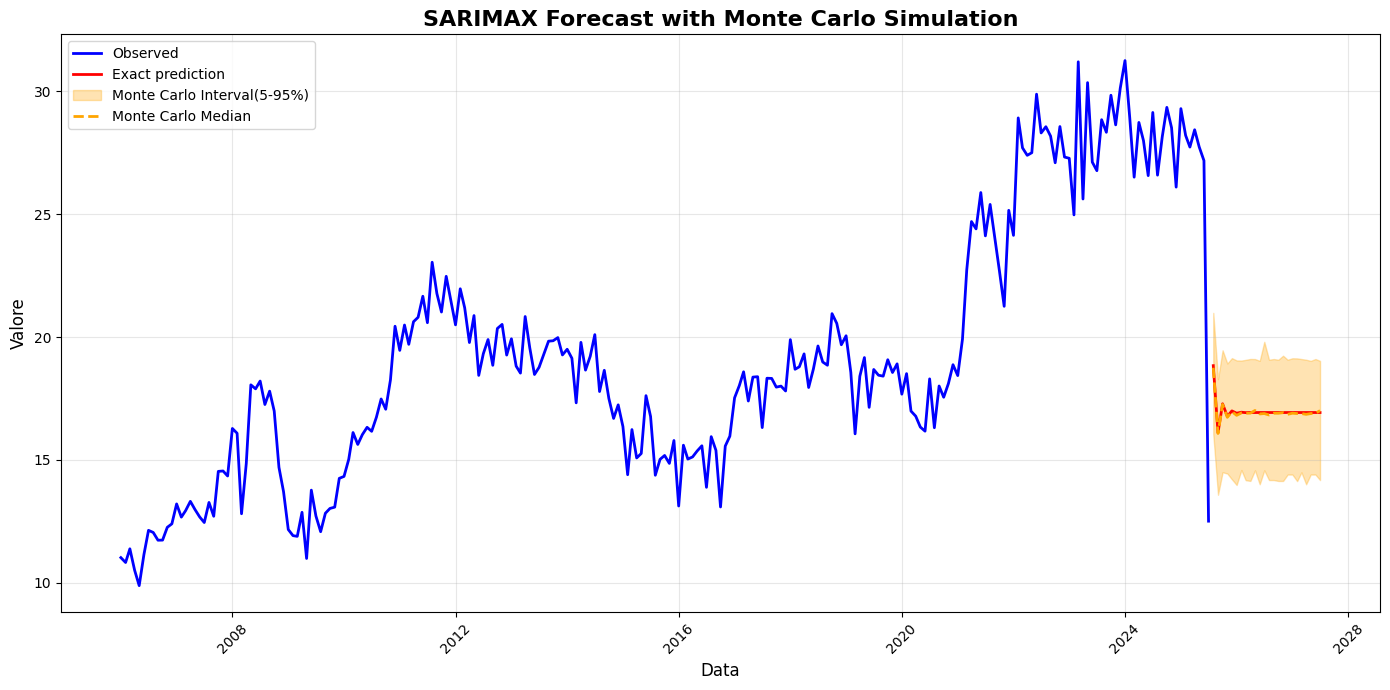

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parametri Monte Carlo
n_forecast = 24
n_simulations = 1000

# Forecast puntuale dal modello
forecast = final_results.get_forecast(steps=n_forecast)
pred_mean = forecast.predicted_mean

# Residui del modello (rumore stimato)
residuals = risultati1.resid.dropna().values

# Generazione indice futuro coerente
freq = pd.infer_freq(serie.index) or "M"
future_index = pd.date_range(start=serie.index[-1], periods=n_forecast+1, freq=freq)[1:]

# Matrice simulazioni: righe=simulazioni, colonne=periodi
simulations = np.zeros((n_simulations, n_forecast))

for i in range(n_simulations):
    # Rumore casuale campionato dai residui storici
    noise = np.random.choice(residuals, size=n_forecast, replace=True)
    # Serie simulata = forecast + rumore cumulato
    simulations[i, :] = pred_mean.values + noise

# Statistiche Monte Carlo
sim_median = np.median(simulations, axis=0)
sim_lower = np.percentile(simulations, 5, axis=0)   # 5° percentile
sim_upper = np.percentile(simulations, 95, axis=0)  # 95° percentile

# Converti in serie Pandas per plotting
sim_median = pd.Series(sim_median, index=future_index)
sim_lower = pd.Series(sim_lower, index=future_index)
sim_upper = pd.Series(sim_upper, index=future_index)

# --- Plot ---
plt.figure(figsize=(14, 7))

# Storico
plt.plot(serie.index, serie, label="Observed", color="blue", linewidth=2)

# Forecast SARIMAX puntuale
plt.plot(pred_mean.index, pred_mean, color="red", linewidth=2, label="Exact prediction")

# Intervallo Monte Carlo
plt.fill_between(sim_median.index, sim_lower, sim_upper, color="orange", alpha=0.3,
                 label="Monte Carlo Interval(5-95%)")

# Mediana Monte Carlo
plt.plot(sim_median.index, sim_median, color="orange", linewidth=2, linestyle="--",
         label="Monte Carlo Median")

# Migliorie grafiche
plt.title("SARIMAX Forecast with Monte Carlo Simulation", fontsize=16, fontweight="bold")
plt.xlabel("Data", fontsize=12)
plt.ylabel("Valore", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmeksl0kr/wcm6ye4k.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmeksl0kr/z3k4g_z8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54418', 'data', 'file=/tmp/tmpmeksl0kr/wcm6ye4k.json', 'init=/tmp/tmpmeksl0kr/z3k4g_z8.json', 'output', 'file=/tmp/tmpmeksl0kr/prophet_modelp_p64l1z/prophet_model-20250915210733.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:07:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:07:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


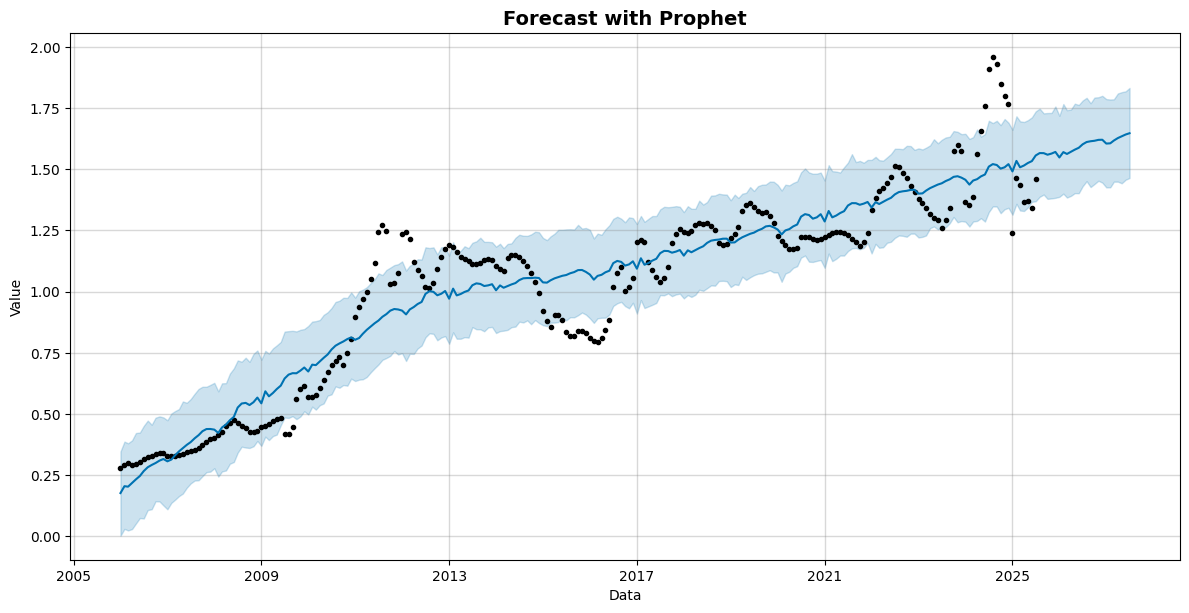

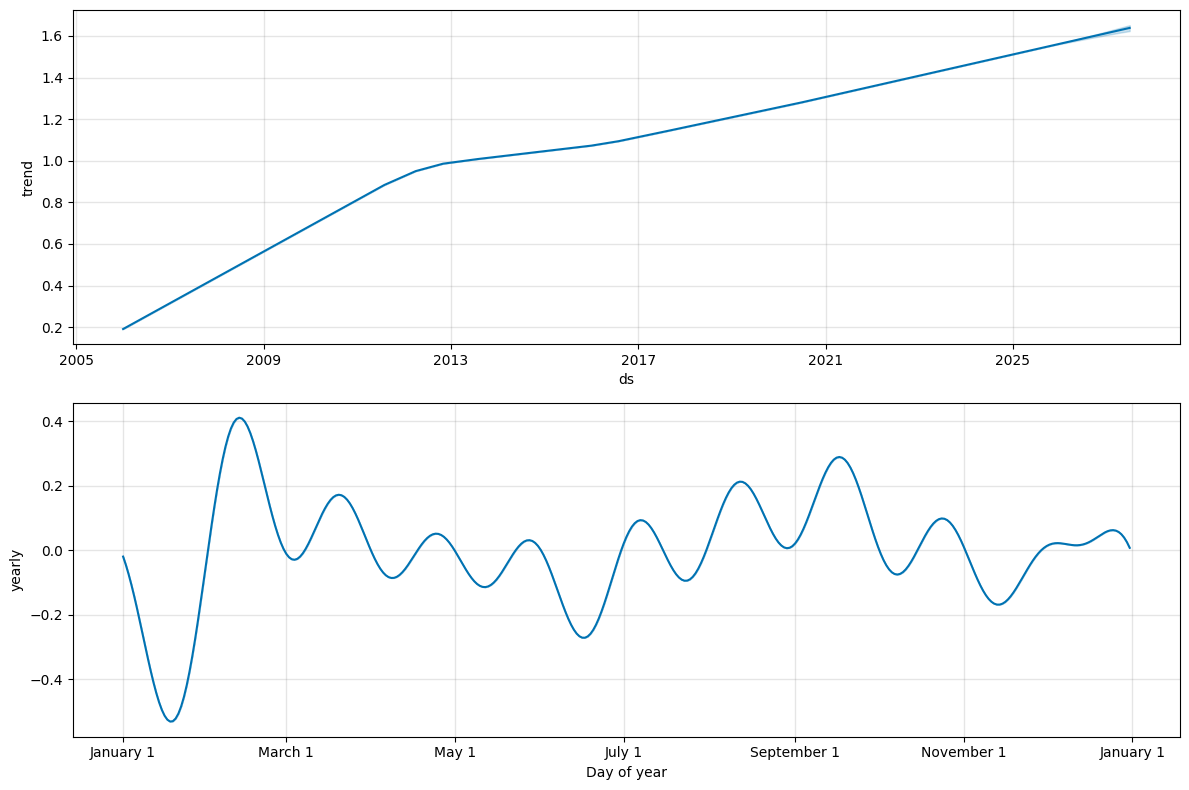

In [72]:

# Preparazione dati per Prophet
df_prophet = serie.reset_index()
df_prophet.columns = ['ds', 'y']  # Prophet richiede 'ds' per data e 'y' per valori

# Modello Prophet
model = Prophet()
model.fit(df_prophet)

# Creazione del dataframe futuro (24 mesi = 2 anni)
future = model.make_future_dataframe(periods=24, freq='MS')  # 'MS' = inizio mese
forecast = model.predict(future)

# Plot previsioni
fig1 = model.plot(forecast, figsize=(12, 6))
plt.title("Forecast with Prophet", fontsize=14, fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.show()

# Componenti (trend, stagionalità, ecc.)
fig2 = model.plot_components(forecast, figsize=(12, 8))
plt.show()